# Hito 1 - Notebook 03: Comprension de Datos y EDA - Frente Salud
## Fase 2 de CRISP-DM (dataset clinico de leucemia)

Analisis exploratorio del dataset clinico en la **cohorte pediatrico-juvenil** (`Age < 25`), alineada con la poblacion atendida por ALDIMI: descripcion de variables, calidad de datos, outliers, correlaciones, pruebas de normalidad y reduccion de dimensionalidad (PCA). Todas las figuras estan tituladas y comentadas.

In [1]:
import sys
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src' / 'aldimi_common.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import aldimi_common as ac
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', None)
print('Raiz del proyecto:', ROOT)

Raiz del proyecto: D:\2026-01\MachLearning\finTF


In [2]:
salud_raw = pd.read_csv(ac.DATA_RAW / ac.HEALTH_RAW_FILE)
n_raw = len(salud_raw)
salud = ac.filter_pediatric_cohort(salud_raw)
print(f'Cohorte pediatrico-juvenil (Age < {ac.HEALTH_MAX_AGE}): {salud.shape[0]:,} pacientes '
      f'(excluidos {n_raw - salud.shape[0]:,} adultos)')
print('Dimensiones:', salud.shape)
salud.head()

Cohorte pediatrico-juvenil (Age < 25): 38,817 pacientes (excluidos 104,377 adultos)
Dimensiones: (38817, 22)


,Patient_ID,Age,Gender,Country,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,Family_History,Smoking_Status,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status
0,2,15,Female,China,4857,4.81,277877,11.9,97,Yes,No,No,No,No,No,28.7,No,No,Ethnic_Group_A,Low,Urban,Positive
1,5,21,Male,Brazil,8342,4.78,309169,14.3,28,No,No,Yes,No,No,No,22.3,No,No,Ethnic_Group_B,Low,Rural,Negative
2,11,24,Male,Russia,13185,4.32,261417,14.2,4,No,No,No,No,No,Yes,25.6,No,No,Ethnic_Group_C,Low,Rural,Negative
3,12,3,Male,China,6973,5.60,295077,11.9,19,No,No,No,No,Yes,No,35.1,No,No,Ethnic_Group_A,Medium,Urban,Negative
4,13,22,Male,Brazil,5545,4.15,182302,11.3,66,No,No,No,Yes,No,No,21.9,Yes,No,Ethnic_Group_A,Low,Rural,Negative


## 1.3.2 Descripcion de los Datos (Diccionario de Variables)

In [3]:
def tipo_variable(s):
    if s.dtype == object:
        return 'Cualitativa Nominal (Dicotomica)' if s.nunique() == 2 else 'Cualitativa Nominal'
    if s.nunique() <= 10:
        return 'Cuantitativa Discreta'
    return 'Cuantitativa Discreta' if str(s.dtype).startswith('int') else 'Cuantitativa Continua'

diccionario = pd.DataFrame({
    '#': range(1, len(salud.columns) + 1),
    'Variable': salud.columns,
    'Tipo_Python': [str(salud[c].dtype) for c in salud.columns],
    'Tipo_Variable': [tipo_variable(salud[c]) for c in salud.columns],
    'Valores_Unicos': [salud[c].nunique() for c in salud.columns],
})
diccionario

,#,Variable,Tipo_Python,Tipo_Variable,Valores_Unicos
0,1,Patient_ID,int64,Cuantitativa Discreta,38817
1,2,Age,int64,Cuantitativa Discreta,24
2,3,Gender,object,Cualitativa Nominal (Dicotomica),2
3,4,Country,object,Cualitativa Nominal,22
4,5,WBC_Count,int64,Cuantitativa Discreta,8953
5,6,RBC_Count,float64,Cuantitativa Continua,354
6,7,Platelet_Count,int64,Cuantitativa Discreta,34892
7,8,Hemoglobin_Level,float64,Cuantitativa Continua,149
8,9,Bone_Marrow_Blasts,int64,Cuantitativa Discreta,100
9,10,Genetic_Mutation,object,Cualitativa Nominal (Dicotomica),2


> El dataset combina variables **demograficas** (Age, Gender, Country, Ethnicity), **hematologicas** (WBC, RBC, Platelet, Hemoglobin, Blasts), **clinicas/geneticas** (Genetic_Mutation, Immune_Disorders, Chronic_Illness), **de habitos** (Smoking, Alcohol, Radiation) y **socioeconomicas** (Socioeconomic_Status, Urban_Rural). El objetivo original es `Leukemia_Status`.

In [4]:
num_cols = salud.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'Patient_ID']
cat_cols = salud.select_dtypes(include='object').columns.tolist()
print('Numericas :', num_cols)
print('Categoricas:', cat_cols)

Numericas : ['Age', 'WBC_Count', 'RBC_Count', 'Platelet_Count', 'Hemoglobin_Level', 'Bone_Marrow_Blasts', 'BMI']
Categoricas: ['Gender', 'Country', 'Genetic_Mutation', 'Family_History', 'Smoking_Status', 'Alcohol_Consumption', 'Radiation_Exposure', 'Infection_History', 'Chronic_Illness', 'Immune_Disorders', 'Ethnicity', 'Socioeconomic_Status', 'Urban_Rural', 'Leukemia_Status']


## 1.3.3 Verificacion de Calidad de los Datos

### Valores nulos y duplicados

In [5]:
nulos = salud.isna().sum()
print('Total de valores nulos:', int(nulos.sum()))
print('Filas duplicadas       :', int(salud.duplicated().sum()))
nulos[nulos > 0] if nulos.sum() > 0 else print('No hay columnas con nulos.')

Total de valores nulos:

 0
Filas duplicadas       : 0
No hay columnas con nulos.


### Estadisticas descriptivas

In [6]:
salud[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,38817.0,12.497102,6.916003,1.00,6.00,13.0,18.00,24.00
WBC_Count,38817.0,6996.198676,2008.096947,-1602.00,5641.00,7021.0,8347.00,14651.00
RBC_Count,38817.0,5.001396,0.500035,2.94,4.66,5.0,5.34,7.15
Platelet_Count,38817.0,249712.222557,49820.355983,55699.00,216158.00,249837.0,283470.00,460325.00
Hemoglobin_Level,38817.0,13.492292,1.998517,5.10,12.10,13.5,14.90,21.50
Bone_Marrow_Blasts,38817.0,49.393745,28.809215,0.00,24.00,49.0,74.00,99.00
BMI,38817.0,25.018355,5.009846,5.40,21.70,25.0,28.40,45.80


### Deteccion de outliers - Boxplots (Figura 1)

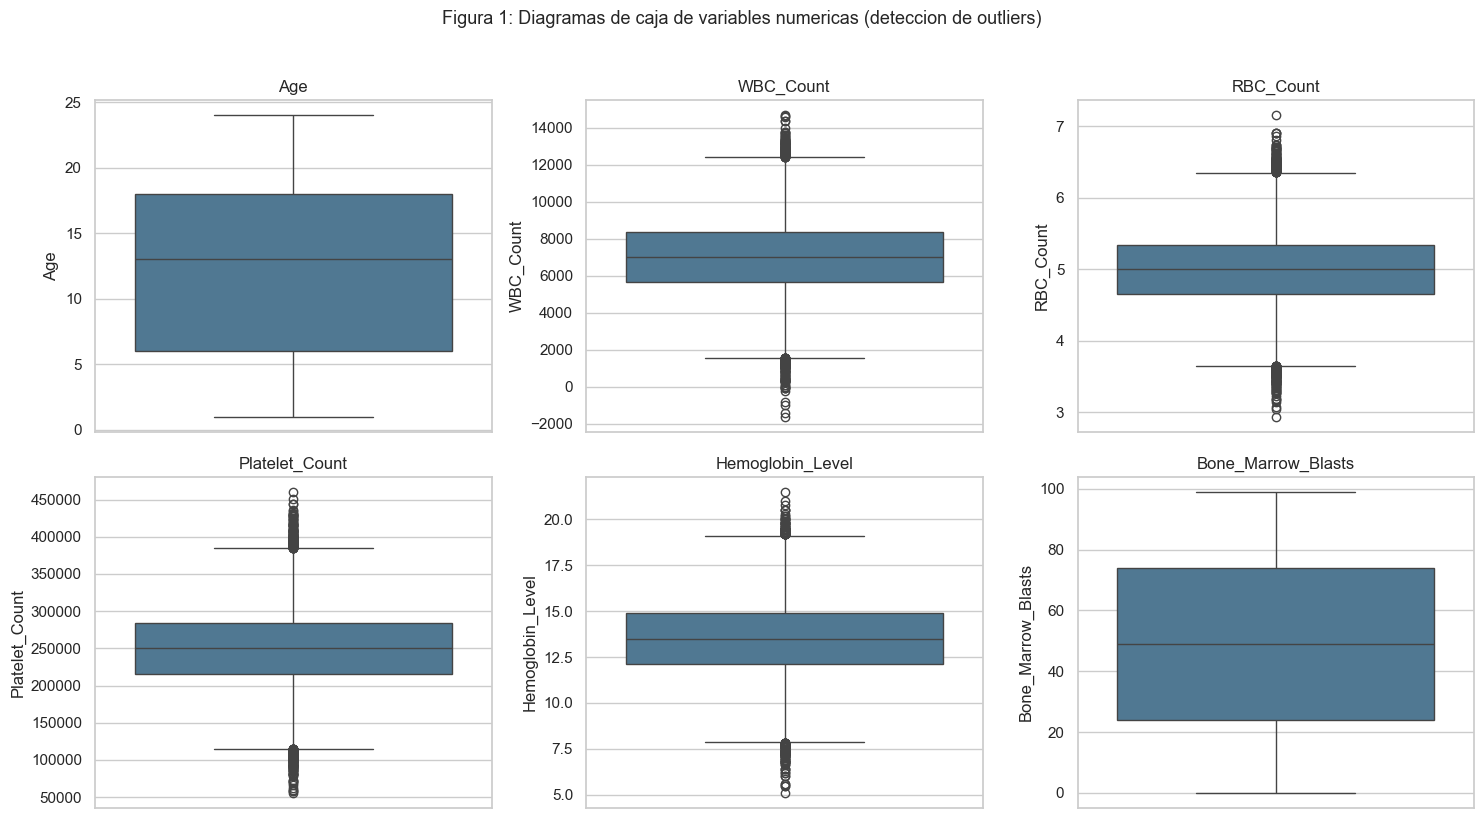

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols[:6]):
    sns.boxplot(y=salud[col], ax=ax, color='#457b9d')
    ax.set_title(col)
fig.suptitle('Figura 1: Diagramas de caja de variables numericas (deteccion de outliers)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 1.** Los marcadores hematologicos (WBC, Platelet) muestran colas y valores extremos propios de datos clinicos. No se eliminan indiscriminadamente: un valor extremo puede representar justamente un caso critico relevante.

### Metodo Z-score

In [8]:
from scipy import stats
z = np.abs(stats.zscore(salud[num_cols], nan_policy='omit'))
outliers_z = (z > 3).sum(axis=0)
tabla_out = pd.DataFrame({'Variable': num_cols, 'Outliers_|Z|>3': outliers_z,
                          'Pct': (outliers_z / len(salud) * 100).round(2)})
tabla_out

,Variable,Outliers_|Z|>3,Pct
Age,Age,0,0.00
WBC_Count,WBC_Count,82,0.21
RBC_Count,RBC_Count,108,0.28
Platelet_Count,Platelet_Count,113,0.29
Hemoglobin_Level,Hemoglobin_Level,94,0.24
Bone_Marrow_Blasts,Bone_Marrow_Blasts,0,0.00
BMI,BMI,108,0.28


> **Tratamiento de outliers:** dada su naturaleza clinica, se opta por **conservarlos** (son informativos) y mitigar su efecto mediante **estandarizacion (StandardScaler)** y modelos basados en arboles (robustos a escala) en la fase de modelado, en lugar de eliminarlos.

### Analisis de correlacion - Matriz de correlacion (Figura 2)

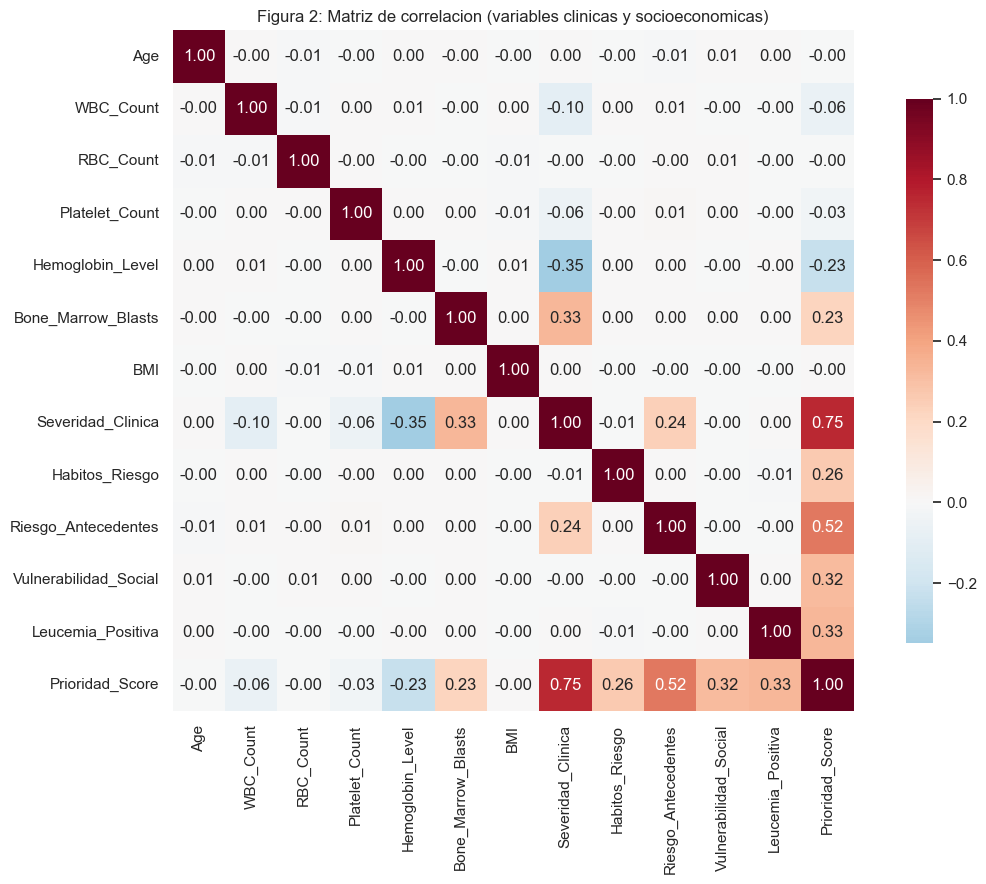

In [9]:
salud_fe = ac.add_health_features(salud)
cols_corr = num_cols + ['Severidad_Clinica', 'Habitos_Riesgo', 'Riesgo_Antecedentes',
                        'Vulnerabilidad_Social', 'Leucemia_Positiva', 'Prioridad_Score']
corr = salud_fe[cols_corr].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Figura 2: Matriz de correlacion (variables clinicas y socioeconomicas)')
plt.tight_layout(); plt.show()

> **Figura 2.** El `Prioridad_Score` correlaciona con `Severidad_Clinica`, `Leucemia_Positiva` y `Vulnerabilidad_Social`, confirmando que la prioridad captura tanto la gravedad clinica como el componente social (ODS 10).

### Matriz de covarianza

In [10]:
cov = salud_fe[num_cols].cov()
cov.round(2)

,Age,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,BMI
Age,47.83,-7.51,-0.02,-8.010800e+02,0.04,-0.07,-0.11
WBC_Count,-7.51,4032453.35,-7.94,4.424209e+04,33.54,-148.37,5.56
RBC_Count,-0.02,-7.94,0.25,-1.437000e+01,-0.00,-0.05,-0.03
Platelet_Count,-801.08,44242.09,-14.37,2.482068e+09,195.00,2296.15,-1662.39
Hemoglobin_Level,0.04,33.54,-0.00,1.950000e+02,3.99,-0.13,0.05
Bone_Marrow_Blasts,-0.07,-148.37,-0.05,2.296150e+03,-0.13,829.97,0.09
BMI,-0.11,5.56,-0.03,-1.662390e+03,0.05,0.09,25.10


### Analisis de multicolinealidad (VIF)

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
Xv = StandardScaler().fit_transform(salud_fe[num_cols].fillna(0))
vif = pd.DataFrame({'Variable': num_cols,
                    'VIF': [variance_inflation_factor(Xv, i) for i in range(Xv.shape[1])]})
vif.sort_values('VIF', ascending=False)

,Variable,VIF
2,RBC_Count,1.000275
6,BMI,1.000224
1,WBC_Count,1.000139
4,Hemoglobin_Level,1.000121
0,Age,1.000077
3,Platelet_Count,1.000057
5,Bone_Marrow_Blasts,1.000026


> **Conclusion VIF:** valores de VIF cercanos a 1 indican baja multicolinealidad entre los marcadores hematologicos; no hay redundancia severa que obligue a eliminar variables antes del modelado.

### Graficos de dispersion (Figura 3)

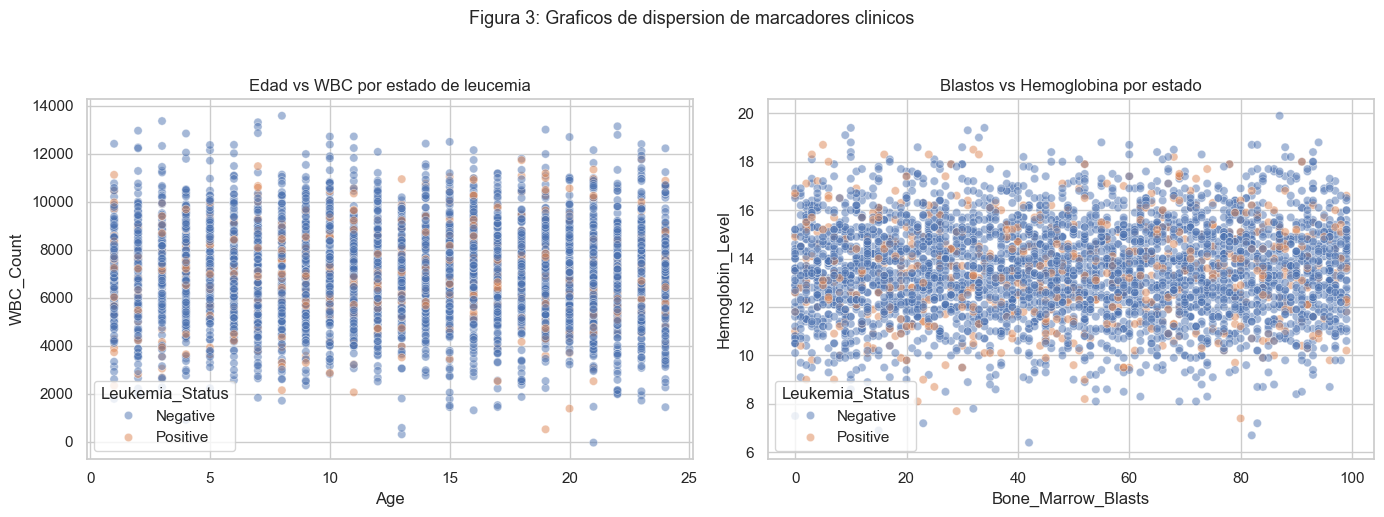

In [12]:
muestra = salud_fe.sample(min(4000, len(salud_fe)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=muestra, x='Age', y='WBC_Count', hue='Leukemia_Status', alpha=.5, ax=axes[0])
axes[0].set_title('Edad vs WBC por estado de leucemia')
sns.scatterplot(data=muestra, x='Bone_Marrow_Blasts', y='Hemoglobin_Level', hue='Leukemia_Status', alpha=.5, ax=axes[1])
axes[1].set_title('Blastos vs Hemoglobina por estado')
fig.suptitle('Figura 3: Graficos de dispersion de marcadores clinicos', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 3.** Los casos positivos tienden a concentrarse en zonas de mayor porcentaje de blastos, reforzando el valor predictivo de los marcadores de medula osea.

## Pruebas de Normalidad

In [13]:
from scipy import stats
filas = []
for col in num_cols:
    datos = salud[col].dropna().sample(min(5000, salud[col].notna().sum()), random_state=42)
    W, p = stats.shapiro(datos)
    filas.append({'Variable': col, 'Shapiro_W': round(W, 4), 'p_value': round(p, 6),
                  'Normal_(a=0.05)': 'Si' if p > 0.05 else 'No'})
pd.DataFrame(filas)

,Variable,Shapiro_W,p_value,Normal_(a=0.05)
0,Age,0.9504,0.000000,No
1,WBC_Count,0.9996,0.376974,Si
2,RBC_Count,0.9996,0.418729,Si
3,Platelet_Count,0.9997,0.611616,Si
4,Hemoglobin_Level,0.9994,0.085975,Si
5,Bone_Marrow_Blasts,0.9544,0.000000,No
6,BMI,0.9997,0.616734,Si


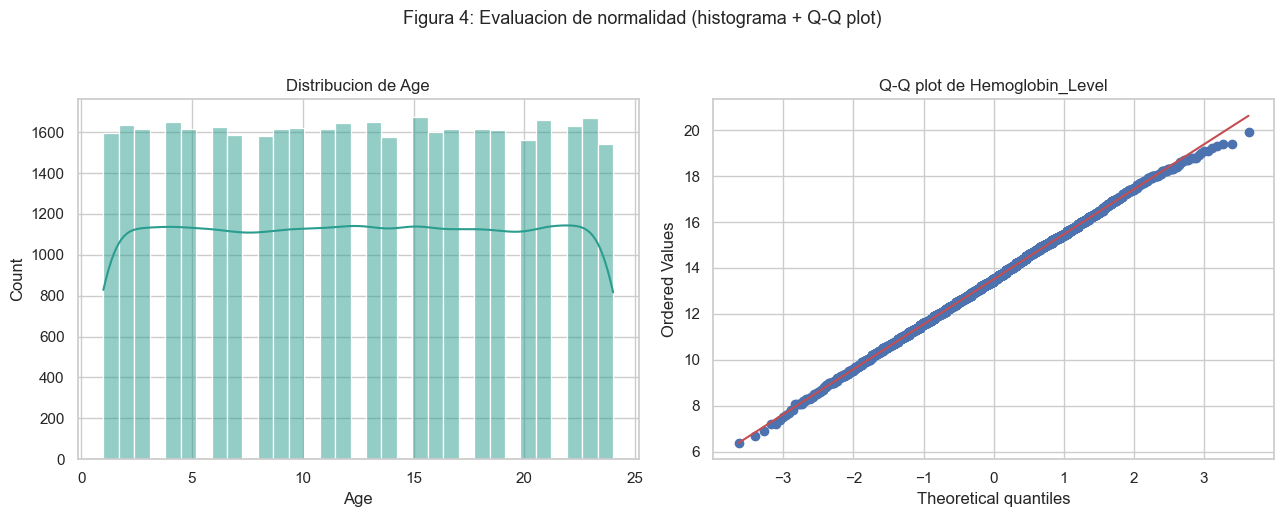

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(salud['Age'], kde=True, ax=axes[0], color='#2a9d8f'); axes[0].set_title('Distribucion de Age')
stats.probplot(salud['Hemoglobin_Level'].dropna().sample(5000, random_state=42), plot=axes[1])
axes[1].set_title('Q-Q plot de Hemoglobin_Level')
fig.suptitle('Figura 4: Evaluacion de normalidad (histograma + Q-Q plot)', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 4 / Conclusion normalidad:** las pruebas de Shapiro-Wilk rechazan la normalidad (p < 0.05) en la mayoria de variables. Esto **justifica** el uso de **correlacion de Spearman** en la exploracion y de **modelos no parametricos basados en arboles** (Random Forest, XGBoost) en el modelado.

## 1.3.4 Analisis Exploratorio de Datos (EDA)

### Distribuciones e histogramas relevantes (Figura 5)

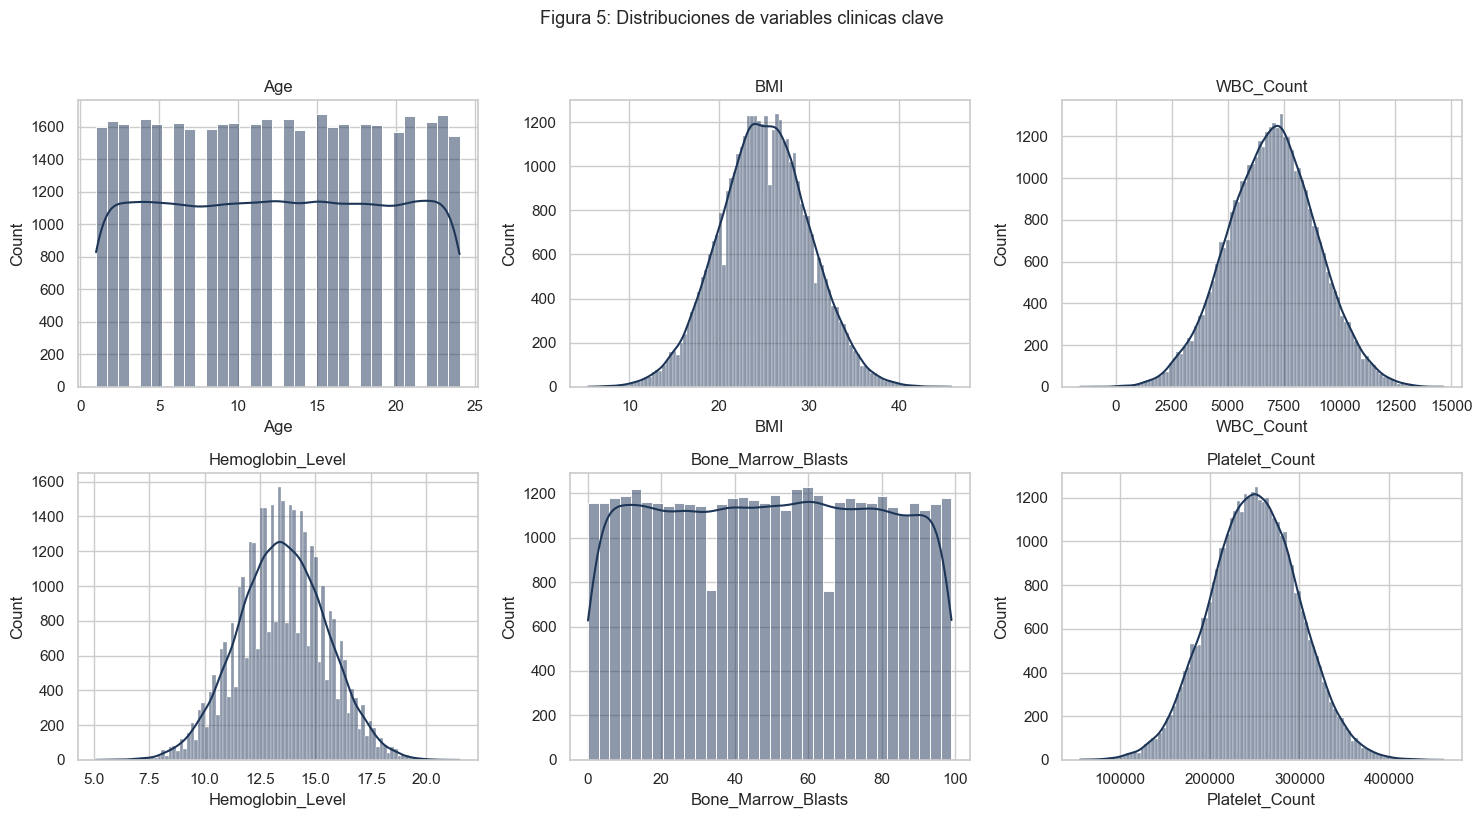

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ['Age', 'BMI', 'WBC_Count', 'Hemoglobin_Level', 'Bone_Marrow_Blasts', 'Platelet_Count']):
    sns.histplot(salud[col], kde=True, ax=ax, color='#1d3557'); ax.set_title(col)
fig.suptitle('Figura 5: Distribuciones de variables clinicas clave', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 5.** Age se distribuye de forma amplia (poblacion mixta); los marcadores hematologicos presentan asimetrias tipicas de datos biologicos.

### Heatmap clinico-socioeconomico y distribucion del objetivo derivado (Figura 6)

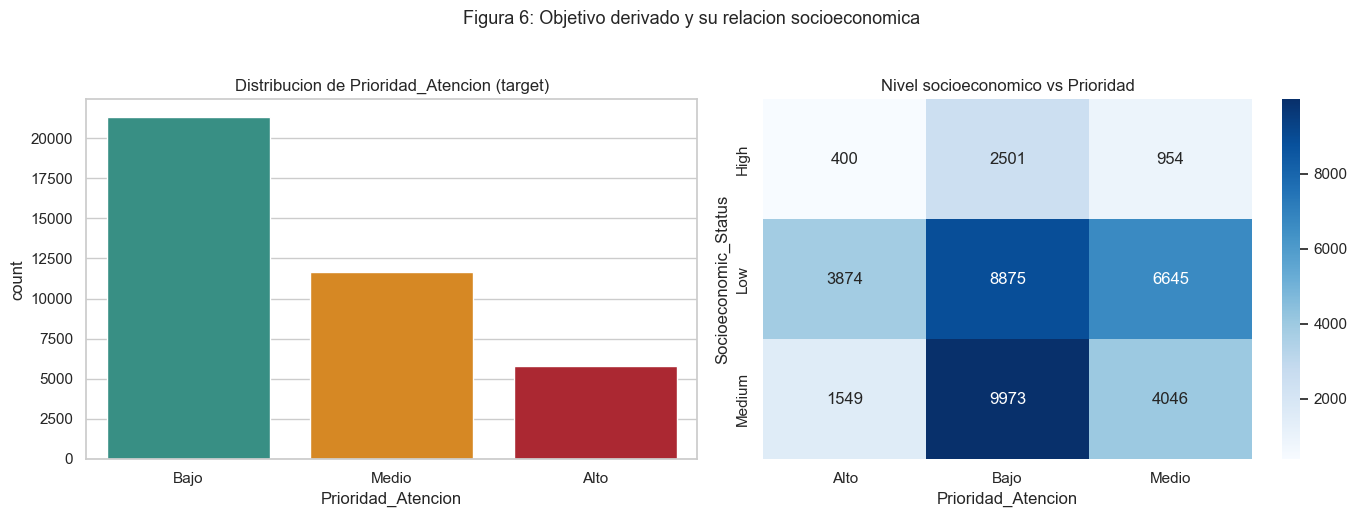

In [16]:
salud_lab = ac.derive_priority_label(salud_fe)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden = ac.PRIORITY_ORDER
sns.countplot(x=salud_lab['Prioridad_Atencion'].astype(str), order=orden, ax=axes[0],
              palette=[ac.PRIORITY_COLORS[k] for k in orden])
axes[0].set_title('Distribucion de Prioridad_Atencion (target)')
tab = pd.crosstab(salud_lab['Socioeconomic_Status'], salud_lab['Prioridad_Atencion'].astype(str))
sns.heatmap(tab, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Nivel socioeconomico vs Prioridad')
fig.suptitle('Figura 6: Objetivo derivado y su relacion socioeconomica', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 6.** El objetivo `Prioridad_Atencion` presenta **desbalance de clases** (menos casos 'Alto'), lo que motiva el uso de **SMOTE** en el modelado. Ademas, los niveles socioeconomicos bajos concentran mayor proporcion de prioridad alta (coherente con el ODS 10).

### Top categorias (Figura 7)

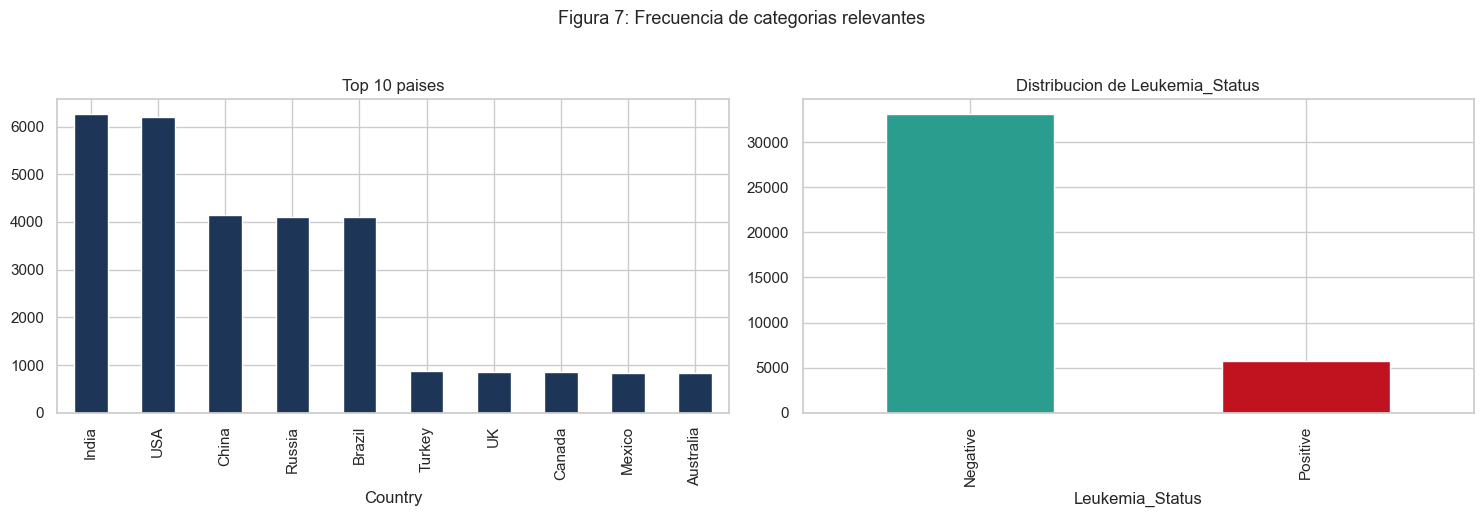

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
salud['Country'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='#1d3557')
axes[0].set_title('Top 10 paises')
salud['Leukemia_Status'].value_counts().plot(kind='bar', ax=axes[1], color=['#2a9d8f', '#c1121f'])
axes[1].set_title('Distribucion de Leukemia_Status')
fig.suptitle('Figura 7: Frecuencia de categorias relevantes', y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

> **Figura 7.** La base es multi-pais; `Leukemia_Status` esta relativamente balanceado, pero el objetivo derivado de prioridad no lo esta.

## Reduccion de Dimensionalidad (PCA)

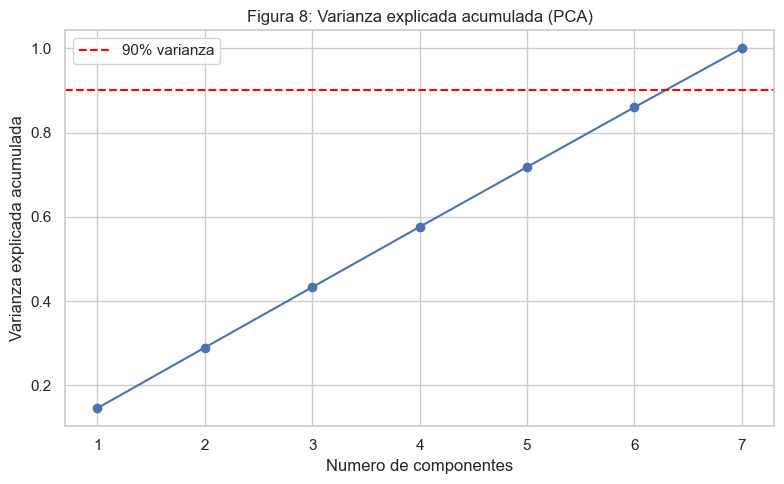

Componentes para explicar 90% de la varianza: 7 de 7


In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(salud_fe[num_cols].fillna(0))
pca = PCA().fit(Xs)
var_acum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(0.9, color='red', ls='--', label='90% varianza')
plt.xlabel('Numero de componentes'); plt.ylabel('Varianza explicada acumulada')
plt.title('Figura 8: Varianza explicada acumulada (PCA)'); plt.legend(); plt.tight_layout(); plt.show()
n90 = int(np.argmax(var_acum >= 0.9) + 1)
print(f'Componentes para explicar 90% de la varianza: {n90} de {len(num_cols)}')

> **Figura 8 / Conclusion PCA:** se requieren varios componentes para alcanzar el 90% de la varianza, lo que indica que las variables clinicas aportan informacion **no redundante**. Por ello, en lugar de comprimir con PCA (que reduce interpretabilidad clinica), en la preparacion se privilegia la **seleccion de variables** conservando el significado medico. El PCA se reporta como analisis de estructura.

## Conclusiones del EDA (Salud)

- Datos completos (sin nulos) y sin duplicados relevantes.
- Outliers clinicos informativos: se conservan y se tratan por escalado/arboles.
- Variables no normales -> se justifican modelos no parametricos.
- Objetivo `Prioridad_Atencion` **desbalanceado** -> se aplicara SMOTE.
- Componente social relevante -> alineacion con ODS 10.